In [13]:
# run this by itself to run r 
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [14]:
%%R 
library(tidyverse)
train<- read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')

Rows: 10886 Columns: 12
-- Column specification --------------------------------------------------------
Delimiter: ","
dbl  (11): season, holiday, workingday, weather, temp, atemp, humidity, wind...
dttm  (1): datetime

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [15]:
%%R 
head(train$datetime)

[1] "2011-01-01 00:00:00 UTC" "2011-01-01 01:00:00 UTC"
[3] "2011-01-01 02:00:00 UTC" "2011-01-01 03:00:00 UTC"
[5] "2011-01-01 04:00:00 UTC" "2011-01-01 05:00:00 UTC"


In [16]:
%%R 
train$year <- substring(train$datetime, 1, 4) # extract year
train$month <- substring(train$datetime, 6, 7) # extract month
train$day <- substring(train$datetime, 9, 10) # extract day

In [17]:
%%R
table(train$year)
table(train$month)
table(train$day)


 01  02  03  04  05  06  07  08  09  10  11  12  13  14  15  16  17  18  19 
575 573 573 574 575 572 574 574 575 572 568 573 574 574 574 574 575 563 574 


In [18]:
%%R
train$day <- weekdays(as.Date(train$datetime))
table(train$day)


   Friday    Monday  Saturday    Sunday  Thursday   Tuesday Wednesday 
     1529      1551      1584      1579      1553      1539      1551 


In [19]:
%%R
aggregate(count~day, mean, data=train)

        day    count
1    Friday 197.8443
2    Monday 190.3907
3  Saturday 196.6654
4    Sunday 180.8398
5  Thursday 197.2962
6   Tuesday 189.7238
7 Wednesday 188.4113


In [21]:
%%R
train$hour <- substring(train$datetime, 12, 13) # extract hour
table(train$hour)


     01  02  03  04  05  06  07  08  09  10  11  12  13  14  15  16  17  18  19 
455 454 448 433 442 452 455 455 455 455 455 455 456 456 456 456 456 456 456 456 
 20  21  22  23 
456 456 456 456 


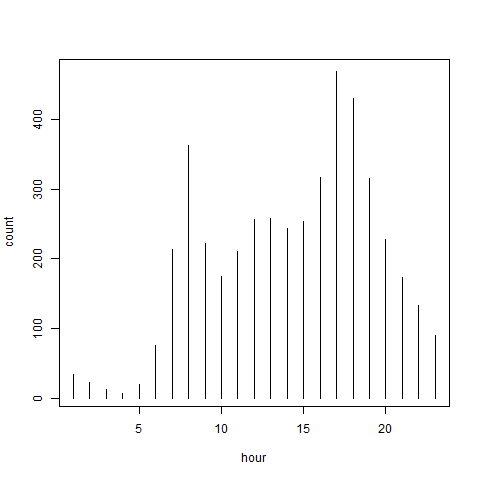

In [23]:
%%R
plot(aggregate(count~hour, mean, data=train), type= 'h')

In [24]:
%%R
# 2/18 assignment
lm(count~hour+day, data=train)


Call:
lm(formula = count ~ hour + day, data = train)

Coefficients:
 (Intercept)        hour01        hour02        hour03        hour04  
     61.4043      -21.2852      -32.2939      -43.3855      -48.6722  
      hour05        hour06        hour07        hour08        hour09  
    -35.4401       21.1209      157.9780      307.6308      166.6418  
      hour10        hour11        hour12        hour13        hour14  
    119.9538      155.5363      201.3761      202.6546      188.3103  
      hour15        hour16        hour17        hour18        hour19  
    199.1655      261.2401      413.6327      375.7270      260.1458  
      hour20        hour21        hour22        hour23     dayMonday  
    173.3848      118.2379       78.4441       34.3761       -7.6446  
 daySaturday     daySunday   dayThursday    dayTuesday  dayWednesday  
     -0.3422      -16.7055       -0.5179       -8.8944       -9.6308  

